#Are usually the users who utilize social media frequently and in a fragmented time span (high Daily_Usage_Time + high number of frequent interactions) prone to negative emotions (Sadness, Anxiety, Anger, Boredom), rather than users with a more low/concentrated usage of the use of social media?

To answer this question I use the data published by Emirhan Bulut on the open-source platform Kaggle, and I engage in their analysis and reuse. To do so, I rely on the following tools:

*   Google Sheets
*   Google Collab
*   Libraries: Seaborn, Numpy, Matplotlib, Pandas










#1. Discovering data

In [4]:
pip install kagglehub[pandas-datasets];

In [5]:
import pandas as pd
df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(1001, 10)


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


I prefer using the sheet's layout because it's more pratical

In [6]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1JNHA1_yQRzCTd9zQbXSdLaI5M2F731SZ-ZtJK-GcSfA/edit#gid=0


Is higher daily social media scrolling time associated with a higher percentage of reported negative emotions?
Let's find out running the following commands.
It's useful to discover the dataset before doing any action on it

In [7]:
df.head (10)

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom
5,6,21,Male,Instagram,150.0,4.0,60.0,15.0,25.0,Happiness
6,7,27,Female,Twitter,85.0,3.0,30.0,10.0,18.0,Anger
7,8,24,Non-binary,Facebook,110.0,6.0,25.0,12.0,22.0,Sadness
8,9,29,Female,LinkedIn,55.0,2.0,10.0,3.0,8.0,Neutral
9,10,31,Male,Instagram,170.0,5.0,80.0,20.0,35.0,Happiness


For visualising all the informations.

In [8]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB


For general information: count, mean, standard deviation, minimum, maximum, quantiles

In [9]:
df.describe()

,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,95.950000,3.321000,39.898000,15.611000,22.560000
std,38.850442,1.914582,26.393867,8.819493,8.516274
min,40.000000,1.000000,5.000000,2.000000,8.000000
25%,65.000000,2.000000,20.000000,8.000000,17.750000
50%,85.000000,3.000000,33.000000,14.000000,22.000000
75%,120.000000,4.000000,55.000000,22.000000,28.000000
max,200.000000,8.000000,110.000000,40.000000,50.000000


After exploring and validating the size and type of the data, I want to skip the joining part for now because I want to use only this dataset. So, let's move on to structuring and cleaning it.

In [10]:
df = df.drop_duplicates()

There's no duplicates in the dataset.

Sanity check

In [11]:
df_clean = df.copy()
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')

for c in ['Age','Daily_Usage_Time (minutes)','Posts_Per_Day','Likes_Received_Per_Day','Comments_Received_Per_Day','Messages_Sent_Per_Day']:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in ['Gender','Platform','Dominant_Emotion']:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

In [12]:
dataset = df_clean
dataset.head(10)

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25.0,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30.0,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22.0,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28.0,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33.0,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom
5,6,21.0,Male,Instagram,150.0,4.0,60.0,15.0,25.0,Happiness
6,7,27.0,Female,Twitter,85.0,3.0,30.0,10.0,18.0,Anger
7,8,24.0,Non-binary,Facebook,110.0,6.0,25.0,12.0,22.0,Sadness
8,9,29.0,Female,LinkedIn,55.0,2.0,10.0,3.0,8.0,Neutral
9,10,31.0,Male,Instagram,170.0,5.0,80.0,20.0,35.0,Happiness


There are Gender's slots with ages, so i'll fix that:

In [40]:
mask = dataset['Gender'].astype(str).str.match(r'^\d+$', na=False)
mask.sum()
#76
dataset[mask].head(76)
dataset.loc[mask, 'Age'] = dataset.loc[mask, 'Gender']
dataset.loc[mask, 'Gender'] = pd.NA

,Gender
0,False
1,False
2,False
3,False
4,False
...,...
996,False
997,False
998,False
999,False


#2. EDA

In [13]:
dataset.describe()

,Age,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,27.461538,95.939061,3.320679,39.891109,15.609391,22.559441
std,3.789033,38.832554,1.913651,26.381568,8.815230,8.512033
min,21.000000,40.000000,1.000000,5.000000,2.000000,8.000000
25%,25.000000,65.000000,2.000000,20.000000,8.000000,18.000000
50%,27.000000,85.000000,3.000000,33.000000,14.000000,22.000000
75%,30.000000,120.000000,4.000000,55.000000,22.000000,28.000000
max,35.000000,200.000000,8.000000,110.000000,40.000000,50.000000


Who spend less time using social media stays 40 min and the longest is 200 min. The mean is 96 min instead the 0.5 quantile is 85

In [14]:
Anger = (dataset['Dominant_Emotion'] == 'Anger').sum()
Sadness =(dataset['Dominant_Emotion'] == 'Sadness').sum()
Boredom = (dataset['Dominant_Emotion'] == 'Boredom').sum()
Anxiety = (dataset['Dominant_Emotion'] == 'Anxiety').sum()
print (Anger, Sadness, Boredom, Anxiety)
Bad_emotions = 0
Bad_emotions = Anger + Sadness + Anxiety + Boredom
print ('Bad emotions are:', Bad_emotions,'so the',
       (Bad_emotions*100)/len(dataset), '% of the dataset')

130 160 140 170
Bad emotions are: 600 so the 59.94005994005994 % of the dataset


Bad emotions are: 600 so the 59.94005994005994 % of the dataset

Daily usage shows high variability (mean ~96 min, std ~39, range 40-200 min).
Most users cluster between 65-120 min (range of IQR), while the gap between the 75th percentile (120 min) and the max (200 min) indicates a small group of heavy users with right-skewed consumption.

Rewards are also highly variable, especially Likes (mean ~40, std ~26, max 110).
This large spread suggests unpredictable, intermittent rewards rather than stable returns, consistent with a variable-ratio reinforcement pattern where a few users receive many likes and most receive few.

In [15]:
dataset.groupby('Dominant_Emotion')['Daily_Usage_Time (minutes)'].agg(['mean','median','count'])

,mean,median,count
Dominant_Emotion,,,
Anger,90.000000,90.0,130
Anxiety,95.588235,75.0,170
Boredom,63.928571,60.0,140
Happiness,150.174129,155.0,201
Neutral,77.750000,72.5,200
Sadness,83.750000,87.5,160


We can observe that negative emotions (Anger 130 + Anxiety 170 + Boredom 140 + Sadness 160 = 600 users) outweigh positive/neutral ones (Happiness 200 + Neutral 200 = 400 users).

In [16]:
dataset.groupby('Platform')['Daily_Usage_Time (minutes)'].agg(['mean','median','count'])

,mean,median,count
Platform,,,
Facebook,72.105263,70.0,190
Instagram,153.127490,150.0,251
LinkedIn,55.833333,55.0,120
Snapchat,90.000000,90.0,80
Telegram,78.125000,80.0,80
Twitter,83.750000,85.0,200
Whatsapp,87.500000,90.0,80


Instagram is the most used platform (251 users), followed by Twitter (200), Facebook (190), LinkedIn (120), and Snapchat, Telegram and Whatsapp tied at 80 each.

Instagram also shows the highest mean (153 min) and median (150 min), more than double LinkedIn (56 min) and Facebook (72 min). Mean and median are very close, so it is not a few outliers: the typical Instagram user systematically uses far more. This pattern is consistent with highly engaging visual design and supports the focus on persuasive design in the HCI section.

In [17]:
dataset.groupby('Platform')[['Posts_Per_Day','Likes_Received_Per_Day','Comments_Received_Per_Day','Messages_Sent_Per_Day']].agg(['mean','median'])

Posts_Per_Day        Likes_Received_Per_Day         \
                   mean median                   mean median   
Platform                                                       
Facebook       1.947368    2.0              19.726316   20.0   
Instagram      5.788845    6.0              79.087649   80.0   
LinkedIn       1.250000    1.0              12.875000   12.0   
Snapchat       2.625000    2.5              30.450000   26.5   
Telegram       2.750000    3.0              29.825000   25.0   
Twitter        3.405000    3.5              35.245000   35.0   
Whatsapp       3.000000    3.0              36.450000   37.0   

          Comments_Received_Per_Day        Messages_Sent_Per_Day         
                               mean median                  mean median  
Platform                                                                 
Facebook                   8.663158    8.5             16.694737   18.0  
Instagram                 26.741036   26.0             33.462151   31.0  
LinkedIn                   5.600000    6.0             12.558333   12.0  
Snapchat                  12.875000   11.0             21.875000   21.0  
Telegram                  12.962500   11.0             21.875000   22.0  
Twitter                   16.575000   18.0             21.170000   22.0  
Whatsapp                  15.162500   12.0             22.125000   21.5

Instagram and LinkedIn are the two poles. Instagram shows the highest values for posts, likes received, comments received and messages sent, while LinkedIn shows the lowest on all four. High reward volume goes together with high usage time (Instagram 153 min vs LinkedIn 56 min), consistent with an intermittent-reward loop: more frequent small rewards sustain longer, fragmented use.

In [18]:
dataset.groupby('Dominant_Emotion')[['Posts_Per_Day','Likes_Received_Per_Day','Comments_Received_Per_Day','Messages_Sent_Per_Day']].agg(['mean','median','count'])

Posts_Per_Day              Likes_Received_Per_Day         \
                          mean median count                   mean median   
Dominant_Emotion                                                            
Anger                 3.700000    4.0   130              38.192308   40.0   
Anxiety               2.994118    2.0   170              40.082353   37.0   
Boredom               1.571429    1.0   140              15.407143   13.0   
Happiness             5.691542    6.0   201              75.407960   78.0   
Neutral               2.400000    2.0   200              27.750000   22.0   
Sadness               3.062500    3.0   160              33.050000   25.0   

                       Comments_Received_Per_Day               \
                 count                      mean median count   
Dominant_Emotion                                                
Anger              130                 18.492308   19.0   130   
Anxiety            170                 15.288235   14.0   170   
Boredom            140                  7.028571    6.0   140   
Happiness          201                 26.860697   26.0   201   
Neutral            200                 10.945000   10.0   200   
Sadness            160                 12.812500   14.0   160   

                 Messages_Sent_Per_Day               
                                  mean median count  
Dominant_Emotion                                     
Anger                        22.369231   22.0   130  
Anxiety                      23.911765   25.0   170  
Boredom                      14.142857   14.0   140  
Happiness                    32.611940   33.0   201  
Neutral                      18.535000   20.0   200  
Sadness                      21.043750   20.0   160

We can observe that Happiness is the peak with high creation and high reward, as also Neutral. Boredom has instead low creation and low reward, while anxiety/anger/sadness show low posting but relatively high likes/messages. They also have frequent small unpredictable rewards sustaining checking.

In [19]:
dataset['Valence'] = 'Positive/Neutral'
dataset.loc[dataset['Dominant_Emotion'].isin(['Anxiety','Sadness','Anger','Boredom']), 'Valence'] = 'Negative'

pd.crosstab(dataset['Platform'], dataset['Valence'], normalize='index') #for %

Valence,Negative,Positive/Neutral
Platform,,
Facebook,0.631579,0.368421
Instagram,0.239044,0.760956
LinkedIn,0.833333,0.166667
Snapchat,0.625000,0.375000
Telegram,0.625000,0.375000
Twitter,0.850000,0.150000
Whatsapp,0.625000,0.375000


Instagram shows the highest share of Positive/Neutral valence, while LinkedIn shows the highest share of Negative valence, possibly linked to job applications and professional performance rather than to usage time alone.

Lastly i'll check the Valence in correlation to median and mean

In [20]:
dataset.groupby('Valence')['Daily_Usage_Time (minutes)'].agg(['mean','median'])

,mean,median
Valence,,
Negative,83.833333,75.0
Positive/Neutral,114.052369,110.0


Analyzing this result we can say that people fell worse due toi the context instead of the time spent. Indeed, the Positive/Neutral group shows higher median usage (110 vs 75 min)

Now i'll analyse variance:
**Thesis:** the mean usage times of the two Valence groups differ.

**Hypotheses:**
- H0: μ1 = μ2+d
  H1: μ1 ≠ μ2+d
The population mean of Group-1 (Negative, n=600) is considered not equal to the population mean of Group-2 (Positive/Neutral, n=401).


**2. P-value**
The p-value equals 2.9e-8. It means the chance of type I error (rejecting a correct H0) is small: 0.0000029%.
The smaller the p-value the more it supports H1.

**3. The statistics**
The test statistic t equals -5.59, which is outside the 95% acceptance region: [-1.96 : 1.96].
x1-x2 = 83.83-114.05 = -30.22, which is outside the 95% acceptance region for the difference.
Welch approximation for df is used (unequal variances, unequal n).

**4. Effect size**
The observed Cohen's d is 0.36 (medium). The magnitude of the mean difference is practically relevant, not only significant.




Now i must check entropy of like distribution between users by Valence.

In [44]:
from scipy.stats import entropy
dataset['Like_bin'] = pd.qcut(dataset['Likes_Received_Per_Day'], q=5, duplicates='drop')
ct = pd.crosstab(dataset['Like_bin'], dataset['Valence'], normalize='columns')
display(ct)
for col in ['Negative','Positive/Neutral']:
    print(col, entropy(ct[col].values, base=2))
# I did not know scipy.stats.entropy beforehand: learned with AI assistance

Valence,Negative,Positive/Neutral
Like_bin,,
"(4.999, 17.0]",0.270000,0.129676
"(17.0, 27.0]",0.220000,0.197007
"(27.0, 40.0]",0.240000,0.149626
"(40.0, 65.0]",0.221667,0.149626
"(65.0, 110.0]",0.048333,0.374065


Negative 2.177787128478088
Positive/Neutral 2.194662367859578


Text(0, 0.5, 'Users number')

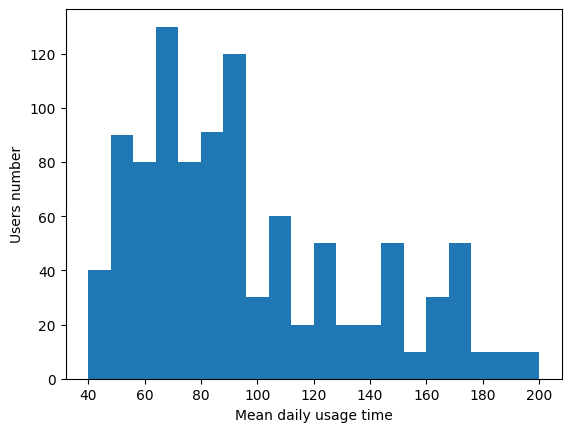

In [21]:
import matplotlib.pyplot as plt
plt.hist(dataset['Daily_Usage_Time (minutes)'], bins = 20)
plt.xlabel('Daily usage time (minutes)')
plt.ylabel('Users number')

Text(0.5, 1.0, 'Negative and positive medians: Daily usage by dominant emotion')

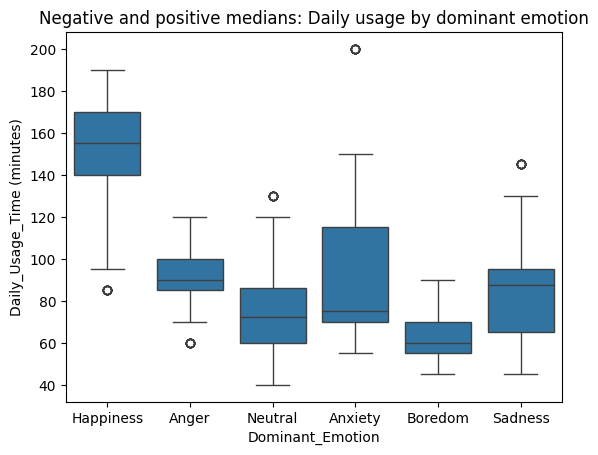

In [41]:
import seaborn as sns
g = sns.boxplot(data=dataset, x='Dominant_Emotion', y='Daily_Usage_Time (minutes)')
g.set_title('Daily usage by dominant emotion')

### Limits
I assume that the combination of high use, the hypnotic design of social media, harsh abusive pattern of pop ups lead to a fragmented screem time. I justified my hypotesis with my knowledge.
Moreover, the dataset used is a scholar/limited dataset and don't include pick up times, only Daily_Usage_Time (minutes).
In conclusion TD-learning is framing not fitted on data.

## Discussion

The data show two poles: Instagram (median 150 min, high likes/comments/messages) and LinkedIn (median 55 min, lowest values). The difference is not only time, but design: endless visual feed, badges and counters exploit a variable-ratio reinforcement schedule, where reward arrives after an unpredictable number of checks, like slot machines. The advertising-based business model rewards dwell time, so the recommender-agent is optimized to keep us engaged.

To read emotions, I use Paul Ekman's distinction between primary emotions (innate and universal: happiness, fear, anger, disgust, sadness, contempt, surprise) and secondary emotions (shame, guilt, jealousy, nostalgia, more linked to culture and cognition). In the dataset I group Anxiety, Sadness, Anger and Boredom as Negative valence (600 users, 60%) and Happiness/Neutrality as Positive/Neutral (400 users). Each has a psychophysiological correlate, but here I focus on the learning mechanism.

The loop can be schematized as reinforcement learning with two agents. On the platform side, the recommender-agent observes the state (history) and chooses the action (what to show) to maximize watch-time. On the user side, the brain-agent learns check values via temporal-difference: delta(t) = r(t) + gamma*V(t+1) - V(t), with update V <- V + epsilon*delta, where epsilon is the learning rate. Dopamine responds to delta, i.e. surprise: likes show high variability (mean 40, std 26, max 110); the between-user entropy of the like distribution is 2.18 bit for the Negative group and 2.19 bit for the Positive/Neutral group (max log2(5)=2.32), indicating equally high spread in both groups with no meaningful difference.

Most common mechanisms keeping dopamine spikes high:

* "Many people need to maintain high self-esteem, i.e. the need to see themselves as respectable, competent and reliable individuals. Faced with the choice between a distorted worldview to feel good about ourselves and an accurate one, we often choose the first" [Social Psychology, Elliot Aronson]. Downward-comparison contents retain us because they temporarily raise self-esteem.

* As shown for divided color attention [Division and spreading of attention across color by Jasna Martinovic, Antoniya Boyanova, Søren K. Andersen], limited perceptual resources split across two targets halve the neural response to the single target, and interference depends on categorization rather than perceptual distance: applied to Instagram multicolor feeds, this explains why notifications, badges and stories fragment selection and sustain continuous checking.

* As in the variable-ratio Skinner box, actions followed by unpredictable rewards are learned and repeated more: we keep checking even knowing it tires us, because intermittent reinforcement keeps expected value high.

## Conclusions

To the opening question: Are users who use social media frequently and in a fragmented time span (high Daily_Usage_Time + high number of frequent interactions) more prone to negative emotions (Sadness, Anxiety, Anger, Boredom) than users with lower/concentrated usage? — the answer is no, not as stated. Positive/Neutral median is higher (110 min vs 75 min for Negative). High usage here goes with high creation and high reward. Happiness is the peak, not Instagram, while the Negative group is pulled down by low-engagement Boredom. The effect is driven by layout and content shaping modus cogitandi, not by time alone.

For HCI this shifts focus from time to mechanism: unpredictable notifications, infinite scroll and counters keep delta high and split attention. The two AI-generated layouts show it: the extractive one extremizes the loop, the ethical one breaks it with paginated feed, batched notifications and no counters, without removing utility.

In conclusion, higher reward volume (likes/comments received) tracks with higher engagement and more positive reported states, while low reinforcement (low posting, few likes) tracks with boredom. Reward unpredictability itself (entropy) does not differ between valence groups, so it does not appear to be the driver of this difference as reward frequency/volume does.